In [ ]:
!pip install torch torchvision
!pip install albumentations

In [ ]:
!pip install dataset

In [ ]:
!pip install torch

In [ ]:
!pip install albumentations

In [ ]:
!pip install dataset

In [ ]:
!pip install torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --index-url https://download.pytorch.org/whl/cu121


### loading your data, preprocessing it, and applying augmentations on-the-fly.

In [8]:
import os
import glob
import torch
import rasterio
import numpy as np
from torch.utils.data import Dataset
import albumentations as A
from torch.utils.data import DataLoader

class GlacialLakeDataset(Dataset):
    """
    Custom Dataset for glacial lake segmentation.
    Handles varying chunk sizes by padding them to a target size.
    """

    def __init__(self, image_dir, mask_dir, augmentations=None, target_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augmentations = augmentations
        self.target_size = target_size # <-- New: Define a target size

        # --- File pairing logic (your code is perfect, no changes needed) ---
        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
        self.pairs = []
        for img_path in self.image_files:
            filename = os.path.basename(img_path)
            if "input_stack_chunk" in filename:
                parts = filename.split("_")
                if len(parts) >= 5:
                    X = parts[1]
                    Y = parts[-1].replace(".tif", "")
                    key = f"LISS3_{X}_lake_mask_chunk_{Y}.tif"
                    mask_path = os.path.join(mask_dir, key)
                    if os.path.exists(mask_path):
                        self.pairs.append((img_path, mask_path))

    def __len__(self):
        return len(self.pairs)

    # Inside the GlacialLakeDataset class

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
    
        # --- ✅ FIX STARTS HERE ---
        # We'll read the image and ALSO store its data type
        with rasterio.open(img_path) as src:
            image = src.read()
            img_dtype = src.profile['dtype'] # <-- Store the dtype here
    
        with rasterio.open(mask_path) as src:
            mask = src.read(1)
        # --- ✅ FIX ENDS HERE ---
        
        # --- Padding logic (no changes needed) ---
        num_channels, original_height, original_width = image.shape
        padded_image = np.zeros((num_channels, self.target_size, self.target_size), dtype=np.float32)
        padded_mask = np.zeros((self.target_size, self.target_size), dtype=np.float32)
        padded_image[:, :original_height, :original_width] = image
        padded_mask[:original_height, :original_width] = mask
    
        image = padded_image
        mask = padded_mask
    
        # --- ✅ USE THE STORED DTYPE HERE ---
        max_val = np.iinfo(img_dtype).max if np.issubdtype(img_dtype, np.integer) else 1.0
        image = image / max_val
        
        # Binarize the mask (no changes needed)
        mask = (mask > 0).astype(np.float32)
        
        if self.augmentations:
            augmented = self.augmentations(image=image.transpose(1, 2, 0), mask=mask)
            image = augmented['image'].transpose(2, 0, 1)
            mask = augmented['mask']
    
        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=0)
    
        return {
            "image": torch.from_numpy(image).float(),
            "mask": torch.from_numpy(mask).float()
        }
    

# --- Your main script to test it ---
if __name__ == '__main__':
    TRAIN_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\train"
    TRAIN_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\train"
    
    BATCH_SIZE = 4
    NUM_WORKERS = 0

    train_transforms = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ])

    print("📦 Loading datasets with padding...")
    # Pass the target_size to the dataset
    train_dataset = GlacialLakeDataset(TRAIN_IMG_DIR, TRAIN_MSK_DIR, train_transforms, target_size=256)

    if len(train_dataset) > 0:
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS
        )

        print("🧪 Verifying one batch...")
        try:
            data_batch = next(iter(train_loader))
            images = data_batch['image']
            masks = data_batch['mask']

            print("✅ Verification successful!")
            print(f"🖼️  Images batch shape: {images.shape}")
            print(f"🛡️  Masks batch shape:  {masks.shape}")
        except RuntimeError as e:
            print(f"🔥 Verification failed after fixes: {e}")
    else:
        print("❌ No data found.")

📦 Loading datasets with padding...
🧪 Verifying one batch...
✅ Verification successful!
🖼️  Images batch shape: torch.Size([4, 8, 256, 256])
🛡️  Masks batch shape:  torch.Size([4, 1, 256, 256])


### Calling Data augmentation class while trianing , below is a sample

In [9]:
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
#from dataset import GlacialLakeDataset  # Use only in .py; comment this out in Jupyter

# --- 1. Define Correct Paths ---
TRAIN_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\train"
TRAIN_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\train"

VAL_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\validate"
VAL_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\validate"

# --- 2. Define Augmentations ---
train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transforms = None

# --- 3. Create Datasets ---
train_dataset = GlacialLakeDataset(
    image_dir=TRAIN_IMG_DIR,
    mask_dir=TRAIN_MSK_DIR,
    augmentations=train_transforms
)

val_dataset = GlacialLakeDataset(
    image_dir=VAL_IMG_DIR,
    mask_dir=VAL_MSK_DIR,
    augmentations=val_transforms
)

# --- 4. Print Stats ---
print(f"✅ Training samples: {len(train_dataset)}")
print(f"✅ Validation samples: {len(val_dataset)}")

# --- 5. Verify One Sample ---
if len(train_dataset) > 0:
    sample = train_dataset[0]
    image_tensor = sample["image"]
    mask_tensor = sample["mask"]

    print("\n🔍 Sample verification:")
    print(f"   🔸 Image tensor shape: {image_tensor.shape}")
    print(f"   🔸 Image tensor dtype: {image_tensor.dtype}")
    print(f"   🔸 Mask tensor shape:  {mask_tensor.shape}")
    print(f"   🔸 Mask tensor dtype:  {mask_tensor.dtype}")
else:
    print("\n⚠️ Training dataset is empty! Check file names or directory paths.")


✅ Training samples: 1777
✅ Validation samples: 222

🔍 Sample verification:
   🔸 Image tensor shape: torch.Size([8, 256, 256])
   🔸 Image tensor dtype: torch.float32
   🔸 Mask tensor shape:  torch.Size([1, 256, 256])
   🔸 Mask tensor dtype:  torch.float32


### Data Loader

This script will import your custom dataset, create instances for your training, validation, and test sets, and then wrap them in DataLoader

In [10]:
import os
import torch
import albumentations as A
from torch.utils.data import DataLoader

# Comment out this import in Jupyter notebooks
# from dataset import GlacialLakeDataset  

# --- Updated Dataset Class ---
import rasterio
import numpy as np
from torch.utils.data import Dataset

class GlacialLakeDataset(Dataset):
    """
    Dataset class for glacial lake segmentation with LISS3 imagery.
    Automatically matches input_stack and lake_mask files using (X, Y) key.
    """

    def __init__(self, image_dir, mask_dir, augmentations=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augmentations = augmentations

        self.pairs = []
        image_files = sorted(os.listdir(image_dir))

        for img_file in image_files:
            if "input_stack_chunk" not in img_file or not img_file.endswith(".tif"):
                continue

            parts = img_file.split("_")
            if len(parts) >= 5:
                X = parts[1]
                Y = parts[-1].replace(".tif", "")
                mask_filename = f"LISS3_{X}_lake_mask_chunk_{Y}.tif"
                img_path = os.path.join(image_dir, img_file)
                mask_path = os.path.join(mask_dir, mask_filename)

                if os.path.exists(mask_path):
                    self.pairs.append((img_path, mask_path))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        with rasterio.open(img_path) as src:
            dtype = src.profile['dtype']
            max_val = np.iinfo(dtype).max if np.issubdtype(dtype, np.integer) else 1.0
            image = src.read() / max_val

        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = (mask > 0).astype(np.float32)

        if self.augmentations:
            augmented = self.augmentations(image=image.transpose(1, 2, 0), mask=mask)
            image = augmented['image'].transpose(2, 1, 0)
            mask = augmented['mask']

        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=0)

        return {
            "image": torch.from_numpy(image).float(),
            "mask": torch.from_numpy(mask).float()
        }

# --- Main block ---
if __name__ == '__main__':
    # --- 1. Paths and Hyperparameters ---
    TRAIN_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\train"
    TRAIN_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\train"

    VAL_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\validate"
    VAL_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\validate"

    BATCH_SIZE = 4
    NUM_WORKERS = 0  # Use 0 for Jupyter

    # --- 2. Augmentations ---
    train_transforms = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ])
    val_transforms = None

    # --- 3. Instantiate Dataset ---
    print("📦 Loading datasets...")
    train_dataset = GlacialLakeDataset(TRAIN_IMG_DIR, TRAIN_MSK_DIR, train_transforms)
    val_dataset = GlacialLakeDataset(VAL_IMG_DIR, VAL_MSK_DIR, val_transforms)

    print(f"✅ Training samples: {len(train_dataset)}")
    print(f"✅ Validation samples: {len(val_dataset)}")

    # --- 4. Create DataLoaders ---
    if len(train_dataset) > 0:
        print("🔄 Creating DataLoaders...")
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True
        )

        # --- 5. Verify One Batch ---
        print("🧪 Verifying training batch...")
        data_batch = next(iter(train_loader))
        images = data_batch['image']
        masks = data_batch['mask']

        print(f"🖼️  Images shape: {images.shape}")
        print(f"🛡️  Masks shape:  {masks.shape}")
        print(f"📏 Image dtype: {images.dtype}")
        print(f"📏 Mask dtype:  {masks.dtype}")
    else:
        print("❌ No data found. Please check your file paths and naming.")


📦 Loading datasets...
✅ Training samples: 1777
✅ Validation samples: 222
🔄 Creating DataLoaders...
🧪 Verifying training batch...


RuntimeError: stack expects each tensor to be equal size, but got [8, 256, 256] at entry 0 and [8, 243, 256] at entry 2

###  The U-Net Model

Here is a standard implementation of the U-Net model in PyTorch. It's composed of two main parts:

DoubleConv: A small helper module that applies two sequential convolution-batchnorm-ReLU layers, which is a repeating block in the U-Net.

UNET: The main class that builds the encoder (downsampling path), bottleneck, and decoder (upsampling path) using the DoubleConv blocks and skip connections.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1 is from the upsampling path, x2 is the skip connection from the downsampling path
        x1 = self.up(x1)
        
        # Pad x1 if its size does not match x2
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        # Concatenate the skip connection tensor (x2) with the upsampled tensor (x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    """Final 1x1 convolution to produce the output segmentation map."""
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNET(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNET, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        # Encoder Path
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)

        # Decoder Path
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        # --- Encoder ---
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # --- Decoder ---
        # The output of each 'down' block is passed as a skip connection to the corresponding 'up' block
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

# --- Verification Script ---
if __name__ == '__main__':
    # Your image has 8 channels (Bands + Indices) and the mask is 1 channel
    in_channels = 8
    out_channels = 1 
    batch_size = 4
    
    # Create a dummy input tensor with the same shape as your data loader's output
    dummy_input = torch.randn(batch_size, in_channels, 256, 256)
    
    # Instantiate the model
    model = UNET(n_channels=in_channels, n_classes=out_channels)
    
    # Pass the dummy input through the model
    output = model(dummy_input)
    
    # Print the shapes to verify
    print("✅ Model Instantiated")
    print(f"Input shape:  {dummy_input.shape}")
    print(f"Output shape: {output.shape}")

    # The output shape should match the input shape in H and W dimensions
    assert dummy_input.shape[0] == output.shape[0]
    assert dummy_input.shape[2] == output.shape[2]
    assert dummy_input.shape[3] == output.shape[3]
    assert output.shape[1] == out_channels
    print("✅ Shape verification successful!")

✅ Model Instantiated
Input shape:  torch.Size([4, 8, 256, 256])
Output shape: torch.Size([4, 1, 256, 256])
✅ Shape verification successful!


### From U-Net to Attention U-Net

The Purpose: The Attention U-Net architecture is designed to focus on important regions while suppressing irrelevant background information. As your proposal mentions, these gates learn to highlight the most salient features being passed from the encoder to the decoder, which is crucial for improving segmentation accuracy in complex areas.



How it Works: The attention gate takes two inputs:

The feature map from the encoder (e.g., x1).

The gating signal from the deeper decoder layer (e.g., x from up1).

It uses the gating signal to produce a "mask" or an "attention map" that it applies to the encoder's feature map. This action effectively tells the decoder to "pay more attention" to specific parts of the skip connection.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# The DoubleConv, Down, and OutConv classes remain exactly the same as before.
# I've included them here so you can copy the whole file easily.

class DoubleConv(nn.Module):
    """(Convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

# --- New Attention Gate Module ---
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        # Convolution for the gating signal (from decoder)
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        # Convolution for the skip connection signal (from encoder)
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        # Final convolution to create the attention map (alpha)
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        # g: Gating signal from the decoder path
        # x: Skip connection from the encoder path
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        
        # Multiply the skip connection 'x' by the attention map 'psi'
        return x * psi

# --- Updated 'Up' Block with Attention ---
class Up(nn.Module):
    """Upscaling then double conv with attention"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True) if bilinear else nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        
        # Create the Attention Gate
        # F_g: Gating signal channels, F_l: Skip connection channels
        self.att = AttentionGate(F_g=in_channels // 2, F_l=in_channels // 2, F_int=in_channels // 4)
        
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1 is from the upsampling path, x2 is the skip connection
        x1 = self.up(x1)
        
        # Get the attention-weighted skip connection
        x2 = self.att(g=x1, x=x2)
        
        # Pad x1 if its size does not match x2
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        # Concatenate and apply convolutions
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

# --- Final Attention UNET Class ---
class AttentionUNET(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(AttentionUNET, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        factor = 2 if bilinear else 1

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

# --- Verification Script ---
if __name__ == '__main__':
    in_channels = 8
    out_channels = 1 
    batch_size = 4
    
    dummy_input = torch.randn(batch_size, in_channels, 256, 256)
    
    # Instantiate the new AttentionUNET model
    model = AttentionUNET(n_channels=in_channels, n_classes=out_channels)
    
    output = model(dummy_input)
    
    print("✅ Attention U-Net Model Instantiated")
    print(f"Input shape:  {dummy_input.shape}")
    print(f"Output shape: {output.shape}")

    assert dummy_input.shape[0] == output.shape[0]
    assert output.shape[1] == out_channels
    assert dummy_input.shape[2] == output.shape[2]
    assert dummy_input.shape[3] == output.shape[3]
    print("✅ Shape verification successful!")

✅ Attention U-Net Model Instantiated
Input shape:  torch.Size([4, 8, 256, 256])
Output shape: torch.Size([4, 1, 256, 256])
✅ Shape verification successful!


### Building the Training Engine

Let's quickly build the components needed to train your AttentionUNET. We'll need:

A Loss Function: We'll start with PyTorch's BCEWithLogitsLoss. It's a standard and numerically stable choice for binary segmentation.

An Optimizer: We'll use Adam, which is a robust, all-around great choice.

A Training Loop: The core script that will handle epochs, batches, forward passes, loss calculation, and backpropagation.

In [7]:
import os
import glob
import torch
import rasterio
import numpy as np
from torch.utils.data import Dataset

class GlacialLakeDataset(Dataset):
    """
    Custom Dataset for glacial lake segmentation.
    Handles varying chunk sizes by padding them to a target size.
    """

    def __init__(self, image_dir, mask_dir, augmentations=None, target_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augmentations = augmentations
        self.target_size = target_size

        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
        self.pairs = []
        for img_path in self.image_files:
            filename = os.path.basename(img_path)
            if "input_stack_chunk" in filename:
                parts = filename.split("_")
                if len(parts) >= 5:
                    # Assumes a pattern like 'LISS3_1_..._chunk_90.tif'
                    scene_id = parts[1]
                    chunk_id = parts[-1].replace(".tif", "")
                    key = f"LISS3_{scene_id}_lake_mask_chunk_{chunk_id}.tif"
                    mask_path = os.path.join(mask_dir, key)
                    if os.path.exists(mask_path):
                        self.pairs.append((img_path, mask_path))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        with rasterio.open(img_path) as src:
            image = src.read()
            img_dtype = src.profile['dtype']

        with rasterio.open(mask_path) as src:
            mask = src.read(1)

        num_channels, original_height, original_width = image.shape
        padded_image = np.zeros((num_channels, self.target_size, self.target_size), dtype=np.float32)
        padded_mask = np.zeros((self.target_size, self.target_size), dtype=np.float32)

        padded_image[:, :original_height, :original_width] = image
        padded_mask[:original_height, :original_width] = mask

        image = padded_image
        mask = padded_mask

        max_val = np.iinfo(img_dtype).max if np.issubdtype(img_dtype, np.integer) else 1.0
        image = image / max_val
        
        mask = (mask > 0).astype(np.float32)
        
        if self.augmentations:
            augmented = self.augmentations(image=image.transpose(1, 2, 0), mask=mask)
            image = augmented['image'].transpose(2, 0, 1)
            mask = augmented['mask']

        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=0)

        return {
            "image": torch.from_numpy(image).float(),
            "mask": torch.from_numpy(mask).float()
        }

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
from tqdm import tqdm
import os


# --- Configuration ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# --- Paths (Update if needed) ---
TRAIN_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\train"
TRAIN_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\train"
VAL_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\validate"
VAL_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\validate"

# --- Hyperparameters ---
LEARNING_RATE = 1e-4
BATCH_SIZE = 4
NUM_EPOCHS = 5
NUM_WORKERS = 0 
IN_CHANNELS = 8
OUT_CHANNELS = 1
MODEL_SAVE_PATH = "attention_unet_model.pth"

def train_one_epoch(loader, model, optimizer, loss_fn, scaler):
    loop = tqdm(loader, leave=True)
    loop.set_description(f"Training Epoch")
    total_loss = 0.0
    
    for batch in loop:
        images = batch["image"].to(DEVICE)
        masks = batch["mask"].to(DEVICE)
        
        # Forward pass with mixed precision if on CUDA
        use_amp = (DEVICE == "cuda")
        with torch.amp.autocast(device_type=DEVICE, enabled=use_amp):
            predictions = model(images)
            loss = loss_fn(predictions, masks)
        
        # Backward pass
        optimizer.zero_grad()
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    return total_loss / len(loader)

def check_accuracy(loader, model, loss_fn):
    dice_score = 0
    model.eval()
    loop = tqdm(loader, leave=True)
    loop.set_description(f"Validation")
    total_val_loss = 0.0

    with torch.no_grad():
        for batch in loop:
            images = batch["image"].to(DEVICE)
            masks = batch["mask"].to(DEVICE)
            
            predictions = model(images)
            total_val_loss += loss_fn(predictions, masks).item()
            
            preds_binary = torch.sigmoid(predictions) > 0.5
            dice_score += (2 * (preds_binary * masks).sum()) / (
                (preds_binary + masks).sum() + 1e-8
            )
            loop.set_postfix(dice=f"{(dice_score / len(loader)):.4f}")

    model.train()
    dice = dice_score / len(loader)
    avg_loss = total_val_loss / len(loader)
    
    print(f"Validation Results: Dice Score = {dice:.4f}, Avg Loss = {avg_loss:.4f}")
    return dice

def main():
    train_dataset = GlacialLakeDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MSK_DIR, target_size=256)
    val_dataset = GlacialLakeDataset(image_dir=VAL_IMG_DIR, mask_dir=VAL_MSK_DIR, target_size=256)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)

    model = AttentionUNET(n_channels=IN_CHANNELS, n_classes=OUT_CHANNELS).to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # ✅ FIXED: Removed the 'device_type' argument
    scaler = torch.amp.GradScaler() if DEVICE == "cuda" else None
    
    best_dice_score = -1.0
    
    for epoch in range(NUM_EPOCHS):
        print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
        train_loss = train_one_epoch(train_loader, model, optimizer, loss_fn, scaler)
        print(f"Average training loss for epoch: {train_loss:.4f}")
        
        current_dice_score = check_accuracy(val_loader, model, loss_fn)
        
        if current_dice_score > best_dice_score:
            best_dice_score = current_dice_score
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"🎉 New best model saved with Dice Score: {best_dice_score:.4f}")

    print("\n✅ Training complete!")

if __name__ == "__main__":
    main()

Using device: cuda

--- Epoch 1/5 ---


Training Epoch: 100%|████████████████████████████████████████████████████| 407/407 [01:46<00:00,  3.81it/s, loss=0.154]


Average training loss for epoch: 0.2568


Validation: 100%|█████████████████████████████████████████████████████████| 51/51 [00:08<00:00,  6.05it/s, dice=0.0000]


Validation Results: Dice Score = 0.0000, Avg Loss = 0.1628
🎉 New best model saved with Dice Score: 0.0000

--- Epoch 2/5 ---


...

Validation Results: Dice Score = 0.0483, Avg Loss = 0.0404

--- Epoch 5/5 ---


Training Epoch: 100%|███████████████████████████████████████████████████| 407/407 [01:22<00:00,  4.96it/s, loss=0.0215]


Average training loss for epoch: 0.0349


Validation: 100%|█████████████████████████████████████████████████████████| 51/51 [00:05<00:00,  9.23it/s, dice=0.1521]

Validation Results: Dice Score = 0.1521, Avg Loss = 0.0321
🎉 New best model saved with Dice Score: 0.1521

✅ Training complete!


### Testing this

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ===================================================================
# CELL 1: DEFINE THE MODEL ARCHITECTURE
# ===================================================================
# (This part is the same as before, ensuring the model can be loaded)
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels: mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels), nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_channels, out_channels))
    def forward(self, x): return self.maxpool_conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1, x1 = self.W_g(g), self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True) if bilinear else nn.ConvTranspose2d(in_channels, in_channels // 2, 2, 2)
        self.att = AttentionGate(F_g=in_channels // 2, F_l=in_channels // 2, F_int=in_channels // 4)
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        x2 = self.att(g=x1, x=x2)
        diffY, diffX = x2.size()[2] - x1.size()[2], x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x): return self.conv(x)

class AttentionUNET(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(AttentionUNET, self).__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128); self.down2 = Down(128, 256); self.down3 = Down(256, 512); self.down4 = Down(512, 1024 // (2 if bilinear else 1))
        self.up1 = Up(1024, 512 // (2 if bilinear else 1), bilinear); self.up2 = Up(512, 256 // (2 if bilinear else 1), bilinear)
        self.up3 = Up(256, 128 // (2 if bilinear else 1), bilinear); self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)
    def forward(self, x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2); x4 = self.down3(x3); x5 = self.down4(x4)
        x = self.up1(x5, x4); x = self.up2(x, x3); x = self.up3(x, x2); x = self.up4(x, x1)
        return self.outc(x)

# ===================================================================
# CELL 2: THE MAIN TESTING LOGIC
# ===================================================================

# --- Configuration ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

MODEL_PATH = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\notebooks\attention_unet_model.pth"
TEST_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\test"
TEST_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\test"
OUTPUT_DIR = "test_predictions_with_stats"
os.makedirs(OUTPUT_DIR, exist_ok=True)
IN_CHANNELS, OUT_CHANNELS = 8, 1

def get_display_image(image_tensor):
    img = image_tensor.squeeze(0).cpu().numpy()
    if img.shape[0] >= 3:
        rgb_img = np.stack([img[2], img[1], img[0]], axis=-1)
        min_val, max_val = rgb_img.min(), rgb_img.max()
        if max_val > min_val: rgb_img = (rgb_img - min_val) / (max_val - min_val)
        return rgb_img
    return img[0]

def test_model(model, test_files):
    model.eval()
    # ✅ Dictionaries to hold the running totals for our metrics
    metrics = {"dice": 0, "iou": 0, "precision": 0, "recall": 0}
    
    for img_path in tqdm(test_files, desc="Testing model"):
        with rasterio.open(img_path) as src:
            image, img_dtype, original_profile = src.read(), src.profile['dtype'], src.profile
        
        num_channels, h, w = image.shape
        padded_image = np.zeros((num_channels, 256, 256), dtype=np.float32)
        padded_image[:, :h, :w] = image
        
        max_val = np.iinfo(img_dtype).max if np.issubdtype(img_dtype, np.integer) else 1.0
        normalized_image = padded_image / max_val
        input_tensor = torch.from_numpy(normalized_image).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            prediction = torch.sigmoid(model(input_tensor)) > 0.5
        
        pred_mask_np = prediction.squeeze().cpu().numpy().astype(np.uint8)
        cropped_pred_mask = pred_mask_np[:h, :w]

        mask_filename = os.path.basename(img_path).replace('input_stack', 'lake_mask')
        true_mask_path = os.path.join(TEST_MSK_DIR, mask_filename)
        true_mask = rasterio.open(true_mask_path).read(1) if os.path.exists(true_mask_path) else np.zeros((h,w), dtype=np.uint8)
        
        # ✅ Calculate metrics for the current image
        tp = np.sum(cropped_pred_mask * true_mask)
        fp = np.sum(cropped_pred_mask * (1 - true_mask))
        fn = np.sum((1 - cropped_pred_mask) * true_mask)
        
        metrics["dice"] += (2. * tp) / (2 * tp + fp + fn + 1e-8)
        metrics["iou"] += tp / (tp + fp + fn + 1e-8)
        metrics["precision"] += tp / (tp + fp + 1e-8)
        metrics["recall"] += tp / (tp + fn + 1e-8)

        # Plotting remains the same...
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1); plt.title("False-Color Image"); plt.imshow(get_display_image(torch.from_numpy(normalized_image).unsqueeze(0))); plt.axis('off')
        plt.subplot(1, 3, 2); plt.title("Ground Truth Mask"); plt.imshow(true_mask, cmap='gray'); plt.axis('off')
        plt.subplot(1, 3, 3); plt.title(f"Model Prediction"); plt.imshow(cropped_pred_mask, cmap='gray'); plt.axis('off')
        base_filename = os.path.basename(img_path).replace("_input_stack", "_prediction")
        plt.savefig(os.path.join(OUTPUT_DIR, base_filename.replace('.tif', '.png')), bbox_inches='tight', dpi=150)
        plt.close()
        
    # ✅ Calculate the average of each metric
    num_files = len(test_files)
    avg_metrics = {key: val / num_files for key, val in metrics.items()}
    return avg_metrics

# --- Main execution ---
print("Loading trained model...")
model = AttentionUNET(n_channels=IN_CHANNELS, n_classes=OUT_CHANNELS).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
print("Model loaded successfully.")

test_image_files = [os.path.join(TEST_IMG_DIR, f) for f in os.listdir(TEST_IMG_DIR) if f.endswith('.tif')]

if not test_image_files:
    print(f"🔥 Error: No test images found in {TEST_IMG_DIR}")
else:
    avg_metrics = test_model(model, test_image_files)
    print(f"\n✅ Testing complete! Predictions are saved in the '{OUTPUT_DIR}' folder.")
    print("\n--- Test Set Performance ---")
    print(f"Dice Score (F1): {avg_metrics['dice']:.4f}")
    print(f"IoU (Jaccard):   {avg_metrics['iou']:.4f}")
    print(f"Precision:       {avg_metrics['precision']:.4f}")
    print(f"Recall:          {avg_metrics['recall']:.4f}")

Using device: cuda
Loading trained model...
Model loaded successfully.


Testing model:   0%|          | 0/204 [00:00<?, ?it/s]


✅ Testing complete! Predictions are saved in the 'test_predictions_with_stats' folder.

--- Test Set Performance ---
Dice Score (F1): 0.0431
IoU (Jaccard):   0.0342
Precision:       0.0719
Recall:          0.0400


### The Complete Sanity Check Cell

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

# ===================================================================
# SETUP: Define Combined Loss and Load Data
# ===================================================================

class DiceBCELoss(nn.Module):
    def __init__(self, weight=0.5, smooth=1e-6):
        super(DiceBCELoss, self).__init__()
        self.weight = weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (probs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        bce_loss = self.bce(logits, targets)
        
        return self.weight * bce_loss + (1 - self.weight) * dice_loss

try:
    train_dataset = GlacialLakeDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MSK_DIR, target_size=256)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    test_dataset = GlacialLakeDataset(image_dir=TEST_IMG_DIR, mask_dir=TEST_MSK_DIR, target_size=256)
    print("✅ Datasets and loader created successfully.")
except NameError:
    print("🔥 Make sure your Dataset class and data paths are defined before running this cell.")
except Exception as e:
    print(f"🔥 An error occurred while creating datasets: {e}")

# ===================================================================
# SANITY CHECK 1: Initial Output of a Fresh Model
# ===================================================================
print("\n--- Running Sanity Check 1: Initial Output ---")
# ✅ FIXED: Changed out_channels to n_classes
fresh_model = AttentionUNET(n_channels=8, n_classes=1).to(DEVICE)
fresh_model.eval()
sample_data = test_dataset[0] 
image = sample_data["image"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    prediction = fresh_model(image)
    prediction_prob = torch.sigmoid(prediction)

print(f"Output range of a fresh model (logits): min={prediction.min():.2f}, max={prediction.max():.2f}")
print(f"Output range after sigmoid (probs):   min={prediction_prob.min():.2f}, max={prediction_prob.max():.2f}")

# ===================================================================
# SANITY CHECK 2: Initial Loss Value
# ===================================================================
print("\n--- Running Sanity Check 2: Initial Loss ---")
try:
    batch = next(iter(train_loader))
    images = batch["image"].to(DEVICE)
    masks = batch["mask"].to(DEVICE)
    loss_fn = DiceBCELoss()
    prediction = fresh_model(images)
    loss = loss_fn(prediction, masks)
    print(f"Initial loss on one batch: {loss.item():.4f}")
except Exception as e:
    print(f"An error occurred: {e}")

# ===================================================================
# SANITY CHECK 3: The Overfitting Test
# ===================================================================
print("\n--- Running Sanity Check 3: The Overfitting Test ---")
try:
    # ✅ FIXED: Changed out_channels to n_classes
    overfit_model = AttentionUNET(n_channels=8, n_classes=1).to(DEVICE)
    overfit_optimizer = optim.Adam(overfit_model.parameters(), lr=1e-3)
    loss_fn = DiceBCELoss()
    
    overfit_model.train()
    for i in tqdm(range(200), desc="Overfitting..."):
        predictions = overfit_model(images)
        loss = loss_fn(predictions, masks)
        overfit_optimizer.zero_grad()
        loss.backward()
        overfit_optimizer.step()
        
    print(f"Final loss after overfitting on one batch: {loss.item():.6f}")
    print("Overfitting test complete. If the final loss is very low (e.g., < 0.01), the model can learn.")
except Exception as e:
    print(f"An error occurred: {e}")

✅ Datasets and loader created successfully.

--- Running Sanity Check 1: Initial Output ---
Output range of a fresh model (logits): min=-0.84, max=0.84
Output range after sigmoid (probs):   min=0.30, max=0.70

--- Running Sanity Check 2: Initial Loss ---
Initial loss on one batch: 0.8411

--- Running Sanity Check 3: The Overfitting Test ---


Overfitting...:   0%|          | 0/200 [00:00<?, ?it/s]

Final loss after overfitting on one batch: 0.132316
Overfitting test complete. If the final loss is very low (e.g., < 0.01), the model can learn.


### A Diagnostic Test

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import torch.nn.functional as F

# ===================================================================
# SETUP: Define the PLAIN U-Net Architecture
# ===================================================================

# NOTE: This is our original U-Net without Attention Gates
class PlainUp(nn.Module):
    """Upscaling then double conv (No Attention)"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNET(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNET, self).__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = PlainUp(1024, 512 // factor, bilinear)
        self.up2 = PlainUp(512, 256 // factor, bilinear)
        self.up3 = PlainUp(256, 128 // factor, bilinear)
        self.up4 = PlainUp(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

# ===================================================================
# DIAGNOSTIC TEST: Overfitting the PLAIN U-Net
# ===================================================================
print("\n--- Running Diagnostic Test: Overfitting the Plain U-Net ---")
try:
    # Use the same batch of images and masks from the previous check
    plain_unet_model = UNET(n_channels=8, n_classes=1).to(DEVICE)
    optimizer = optim.Adam(plain_unet_model.parameters(), lr=1e-3)
    loss_fn = DiceBCELoss()
    
    plain_unet_model.train()
    for i in tqdm(range(200), desc="Overfitting Plain U-Net..."):
        predictions = plain_unet_model(images) # Using the plain U-Net
        loss = loss_fn(predictions, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Final loss after overfitting PLAIN U-Net: {loss.item():.6f}")
    print("If this loss is very low, the problem is in our Attention Gate.")

except Exception as e:
    print(f"An error occurred: {e}")


--- Running Diagnostic Test: Overfitting the Plain U-Net ---


Overfitting Plain U-Net...:   0%|          | 0/200 [00:00<?, ?it/s]

Final loss after overfitting PLAIN U-Net: 0.130714
If this loss is very low, the problem is in our Attention Gate.


### Overfitting Test on the Bug-Fixed U-Net

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import torch.nn.functional as F

# ===================================================================
# SETUP: Define the CORRECTED U-Net Architecture
# ===================================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class BugfixedUNET(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(BugfixedUNET, self).__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        self.up1 = Up(1024 + 512, 512)
        self.up2 = Up(512 + 256, 256)
        self.up3 = Up(256 + 128, 128)
        self.up4 = Up(128 + 64, 64)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

# ===================================================================
# BUG HUNT: Overfitting the Corrected U-Net
# ===================================================================
print("\n--- Running Bug Hunt: Overfitting the Corrected U-Net ---")
try:
    # The 'images' and 'masks' variables from the previous sanity check cell should still be in memory
    bugfixed_model = BugfixedUNET(n_channels=8, n_classes=1).to(DEVICE)
    optimizer = optim.Adam(bugfixed_model.parameters(), lr=1e-3)
    # The DiceBCELoss class should also be defined in a previous cell
    loss_fn = DiceBCELoss()
    
    bugfixed_model.train()
    for i in tqdm(range(200), desc="Overfitting Corrected U-Net..."):
        # ✅ FIXED: Use the 'images' tensor as input every time
        predictions = bugfixed_model(images)
        loss = loss_fn(predictions, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Final loss after overfitting CORRECTED U-Net: {loss.item():.6f}")
    print("This loss should be very close to zero.")

except Exception as e:
    print(f"An error occurred: {e}")


--- Running Bug Hunt: Overfitting the Corrected U-Net ---


Overfitting Corrected U-Net...:   0%|          | 0/200 [00:00<?, ?it/s]

Final loss after overfitting CORRECTED U-Net: 0.481577
This loss should be very close to zero.


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import torch.nn.functional as F

# Make sure the corrected BugfixedUNET and DiceBCELoss classes are defined above this cell

print("--- Running Final Diagnostics ---")

try:
    # ===================================================================
    # DIAGNOSTIC 1: Inspect the Data Batch
    # ===================================================================
    print("\n--- Inspecting the data batch ---")
    # The 'images' and 'masks' variables should still be in your notebook's memory
    # from the last sanity check. Let's inspect them.
    print(f"Images tensor shape: {images.shape}")
    print(f"Images tensor dtype: {images.dtype}")
    print(f"Images tensor min value: {images.min():.4f}")
    print(f"Images tensor max value: {images.max():.4f}")
    print(f"Images tensor mean value: {images.mean():.4f}")
    
    print("-" * 20)
    
    print(f"Masks tensor shape: {masks.shape}")
    print(f"Masks tensor dtype: {masks.dtype}")
    print(f"Masks tensor min value: {masks.min():.4f}")
    print(f"Masks tensor max value: {masks.max():.4f}")
    print(f"Percentage of 'lake' pixels in masks: {(masks.mean() * 100):.2f}%")
    
    # ===================================================================
    # DIAGNOSTIC 2: Aggressive Overfitting Test
    # ===================================================================
    print("\n--- Running Aggressive Overfitting Test on Corrected U-Net ---")

    # Re-create the model to ensure it has fresh weights
    bugfixed_model = BugfixedUNET(n_channels=8, n_classes=1).to(DEVICE)
    # Let's try a slightly different learning rate
    optimizer = optim.Adam(bugfixed_model.parameters(), lr=3e-4) 
    loss_fn = DiceBCELoss()
    
    bugfixed_model.train()
    
    for i in tqdm(range(500), desc="Aggressively overfitting..."): # More iterations
        predictions = bugfixed_model(images)
        loss = loss_fn(predictions, masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Print loss every 50 steps to see the trend
        if (i + 1) % 50 == 0:
            print(f"  Iteration {i+1}, Loss: {loss.item():.6f}")
        
    print(f"\nFinal loss after aggressive overfitting: {loss.item():.6f}")
    print("If this loss is still not near zero, something is fundamentally wrong.")

except NameError:
    print("\n🔥 NameError: Please make sure to run the previous sanity check cell first")
    print("  so that the 'images' and 'masks' variables are created.")
except Exception as e:
    print(f"An error occurred: {e}")

--- Running Final Diagnostics ---

--- Inspecting the data batch ---
Images tensor shape: torch.Size([4, 8, 256, 256])
Images tensor dtype: torch.float32
Images tensor min value: -1.0000
Images tensor max value: 6209.0000
Images tensor mean value: 199.8361
--------------------
Masks tensor shape: torch.Size([4, 1, 256, 256])
Masks tensor dtype: torch.float32
Masks tensor min value: 0.0000
Masks tensor max value: 1.0000
Percentage of 'lake' pixels in masks: 0.19%

--- Running Aggressive Overfitting Test on Corrected U-Net ---


Aggressively overfitting...:   0%|          | 0/500 [00:00<?, ?it/s]

  Iteration 50, Loss: 0.691777
  Iteration 100, Loss: 0.669162
  Iteration 150, Loss: 0.647507
  Iteration 200, Loss: 0.626329
  Iteration 250, Loss: 0.603905
  Iteration 300, Loss: 0.581877
  Iteration 350, Loss: 0.563978
  Iteration 400, Loss: 0.548577
  Iteration 450, Loss: 0.534690
  Iteration 500, Loss: 0.522012

Final loss after aggressive overfitting: 0.522012
If this loss is still not near zero, something is fundamentally wrong.


### Data Normalization 

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import torch.nn.functional as F
import os
import rasterio
import numpy as np
import glob

# ===================================================================
# SETUP: Final Corrected Dataset and Bug-Fixed U-Net
# ===================================================================

class GlacialLakeDataset(Dataset):
    """Dataset with the CORRECT normalization for 10-bit LISS-3 data."""
    def __init__(self, image_dir, mask_dir, augmentations=None, target_size=256):
        self.image_dir, self.mask_dir, self.augmentations, self.target_size = image_dir, mask_dir, augmentations, target_size
        self.pairs = []
        image_files = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
        for img_path in image_files:
            filename = os.path.basename(img_path)
            if "input_stack_chunk" in filename:
                parts = filename.split("_")
                if len(parts) >= 5:
                    scene_id, chunk_id = parts[1], parts[-1].replace(".tif", "")
                    key = f"LISS3_{scene_id}_lake_mask_chunk_{chunk_id}.tif"
                    mask_path = os.path.join(self.mask_dir, key)
                    if os.path.exists(mask_path): self.pairs.append((img_path, mask_path))

    def __len__(self): return len(self.pairs)

# In your GlacialLakeDataset class, replace the __getitem__ method with this one.

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        with rasterio.open(img_path) as src: image = src.read().astype(np.float32)
        with rasterio.open(mask_path) as src: mask = src.read(1).astype(np.float32)
        
        # --- START OF CORRECTION ---
        # ✅ Correctly normalize ALL 8 channels
        
        # Normalize LISS-3 bands (channels 0-3)
        image[:4, :, :] = image[:4, :, :] / 1023.0 
        
        # Normalize topographic bands (channels 4-7)
        # IMPORTANT: Replace these max values with the actual max values from your data
        # For example, find the max elevation in your entire dataset for the DEM.
        DEM_MAX = 4000.0   # Placeholder: Max elevation in meters
        SLOPE_MAX = 90.0   # Placeholder: Max slope in degrees
        ASPECT_MAX = 360.0 # Placeholder: Max aspect in degrees
        NDWI_MAX = 1.0     # NDWI is already -1 to 1, so we can scale it to 0-1
        
        # Note: Check the order of your channels! This is an example.
        image[4, :, :] = image[4, :, :] / DEM_MAX 
        image[5, :, :] = image[5, :, :] / SLOPE_MAX
        image[6, :, :] = image[6, :, :] / ASPECT_MAX
        image[7, :, :] = (image[7, :, :] + 1.0) / 2.0 # Scale NDWI from [-1, 1] to [0, 1]
    
        # Clip all values to be safe
        image = np.clip(image, 0.0, 1.0)
        # --- END OF CORRECTION ---
    
        num_channels, h, w = image.shape
        padded_image = np.zeros((num_channels, self.target_size, self.target_size), dtype=np.float32)
        padded_mask = np.zeros((self.target_size, self.target_size), dtype=np.float32)
        padded_image[:, :h, :w], padded_mask[:h, :w] = image, mask
        
        if self.augmentations:
            augmented = self.augmentations(image=padded_image.transpose(1, 2, 0), mask=padded_mask)
            padded_image, padded_mask = augmented['image'].transpose(2, 0, 1), augmented['mask']
            
        return {"image": torch.from_numpy(padded_image), "mask": torch.from_numpy(padded_mask).unsqueeze(0)}
    
    # --- All other classes (DoubleConv, Down, Up, etc.) and DiceBCELoss remain the same ---
# (Assuming they are in your notebook's memory from the previous cells)


# ===================================================================
# THE MOMENT OF TRUTH: Overfitting with Correct Data
# ===================================================================
print("\n--- Running Final Test: Overfitting with Correctly Normalized Data ---")
try:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    TRAIN_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\train"
    TRAIN_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\train"

    # Reload the data with the FINAL dataset class
    final_test_dataset = GlacialLakeDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MSK_DIR, target_size=256)
    final_test_loader = DataLoader(final_test_dataset, batch_size=4, shuffle=True)
    
    batch_data = next(iter(final_test_loader))
    images = batch_data["image"].to(DEVICE)
    masks = batch_data["mask"].to(DEVICE)

    print("--- Inspected new normalized batch ---")
    print(f"New Images tensor max value: {images.max():.4f}")
    print(f"New Images tensor min value: {images.min():.4f}")
    print("-" * 20)

    # Use the bug-fixed U-Net
    final_model = BugfixedUNET(n_channels=8, n_classes=1).to(DEVICE)
    optimizer = optim.Adam(final_model.parameters(), lr=1e-3)
    loss_fn = DiceBCELoss()
    
    final_model.train()
    for i in tqdm(range(200), desc="Overfitting..."):
        predictions = final_model(images)
        loss = loss_fn(predictions, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"\nFinal loss after overfitting with corrected data: {loss.item():.6f}")
    print("This loss should now be very close to zero!")

except Exception as e:
    print(f"An error occurred: {e}")


--- Running Final Test: Overfitting with Correctly Normalized Data ---
--- Inspected new normalized batch ---
New Images tensor max value: 1.0000
New Images tensor min value: 0.0000
--------------------


Overfitting...:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

# The Data Inspector Script

In [ ]:
import rasterio
import numpy as np
import os

print("--- Running Data Inspector ---")

# --- IMPORTANT ---
# Please provide a path to just ONE of your chunk files.
# Any of the .tif files from your 'train' folder will work.
# For example: r"C:\...\input_stack\train\LISS3_1_input_stack_chunk_1.tif"

try:
    # --- Paste the full path to a single chunk file here ---
    file_path = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\train\LISS3_1_input_stack_chunk_602.tif"

    if not os.path.exists(file_path):
        print(f"🔥 ERROR: File not found at path: {file_path}")
        print("Please make sure the path is correct.")
    else:
        with rasterio.open(file_path) as src:
            print("\n--- File Metadata ---")
            print(f"Data Type (dtype): {src.profile['dtype']}")
            print(f"Number of Channels: {src.count}")
            print(f"NoData Value: {src.nodata}")
            print("-" * 25)

            print("\n--- Per-Channel Statistics ---")
            for i in range(1, src.count + 1):
                # Read the specific channel (band)
                band = src.read(i).astype(np.float32)
                
                # If a NoData value exists, let's ignore it for statistics
                if src.nodata is not None:
                    band[band == src.nodata] = np.nan

                print(f"\n- Channel {i}:")
                print(f"  Min Value:  {np.nanmin(band):.4f}")
                print(f"  Max Value:  {np.nanmax(band):.4f}")
                print(f"  Mean Value: {np.nanmean(band):.4f}")

except Exception as e:
    print(f"An error occurred: {e}")

### Train cell

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import torch.nn.functional as F
import os
import rasterio
import numpy as np
import glob
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ===================================================================
# FINAL, CORRECTED DATASET CLASS
# ===================================================================
class GlacialLakeDataset(Dataset):
    """Dataset with the final, correct normalization for the observed data."""
    def __init__(self, image_dir, mask_dir, augmentations=None, target_size=256):
        self.image_dir, self.mask_dir, self.augmentations, self.target_size = image_dir, mask_dir, augmentations, target_size
        self.pairs = []
        image_files = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
        for img_path in image_files:
            filename = os.path.basename(img_path)
            if "input_stack_chunk" in filename:
                parts = filename.split("_")
                if len(parts) >= 5:
                    scene_id, chunk_id = parts[1], parts[-1].replace(".tif", "")
                    key = f"LISS3_{scene_id}_lake_mask_chunk_{chunk_id}.tif"
                    mask_path = os.path.join(self.mask_dir, key)
                    if os.path.exists(mask_path): self.pairs.append((img_path, mask_path))

    def __len__(self): return len(self.pairs)

    # In your GlacialLakeDataset class, replace the __getitem__ method with this one.

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        with rasterio.open(img_path) as src: image = src.read().astype(np.float32)
        with rasterio.open(mask_path) as src: mask = src.read(1).astype(np.float32)
        
        # --- START OF CORRECTION ---
        # ✅ Correctly normalize ALL 8 channels
        
        # Normalize LISS-3 bands (channels 0-3)
        image[:4, :, :] = image[:4, :, :] / 1023.0 
        
        # Normalize topographic bands (channels 4-7)
        # IMPORTANT: Replace these max values with the actual max values from your data
        # For example, find the max elevation in your entire dataset for the DEM.
        DEM_MAX = 4000.0   # Placeholder: Max elevation in meters
        SLOPE_MAX = 90.0   # Placeholder: Max slope in degrees
        ASPECT_MAX = 360.0 # Placeholder: Max aspect in degrees
        NDWI_MAX = 1.0     # NDWI is already -1 to 1, so we can scale it to 0-1
        
        # Note: Check the order of your channels! This is an example.
        image[4, :, :] = image[4, :, :] / DEM_MAX 
        image[5, :, :] = image[5, :, :] / SLOPE_MAX
        image[6, :, :] = image[6, :, :] / ASPECT_MAX
        image[7, :, :] = (image[7, :, :] + 1.0) / 2.0 # Scale NDWI from [-1, 1] to [0, 1]
    
        # Clip all values to be safe
        image = np.clip(image, 0.0, 1.0)
        # --- END OF CORRECTION ---
    
        num_channels, h, w = image.shape
        padded_image = np.zeros((num_channels, self.target_size, self.target_size), dtype=np.float32)
        padded_mask = np.zeros((self.target_size, self.target_size), dtype=np.float32)
        padded_image[:, :h, :w], padded_mask[:h, :w] = image, mask
        
        if self.augmentations:
            augmented = self.augmentations(image=padded_image.transpose(1, 2, 0), mask=padded_mask)
            padded_image, padded_mask = augmented['image'].transpose(2, 0, 1), augmented['mask']
            
        return {"image": torch.from_numpy(padded_image), "mask": torch.from_numpy(padded_mask).unsqueeze(0)}

# ===================================================================
# FINAL MODEL, LOSS, and TRAINING SCRIPT
# ===================================================================

# --- All Model Building Blocks (DoubleConv, Down, Up, OutConv) ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__(); self.double_conv = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True), nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
    def forward(self, x): return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__(); self.maxpool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_channels, out_channels))
    def forward(self, x): return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__(); self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True); self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x1, x2):
        x1 = self.up(x1); diffY, diffX = x2.size()[2] - x1.size()[2], x2.size()[3] - x1.size()[3]; x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2]); x = torch.cat([x2, x1], dim=1); return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__(); self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x): return self.conv(x)

class BugfixedUNET(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(BugfixedUNET, self).__init__(); self.inc = DoubleConv(n_channels, 64); self.down1 = Down(64, 128); self.down2 = Down(128, 256); self.down3 = Down(256, 512); self.down4 = Down(512, 1024); self.up1 = Up(1024 + 512, 512); self.up2 = Up(512 + 256, 256); self.up3 = Up(256 + 128, 128); self.up4 = Up(128 + 64, 64); self.outc = OutConv(64, n_classes)
    def forward(self, x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2); x4 = self.down3(x3); x5 = self.down4(x4); x = self.up1(x5, x4); x = self.up2(x, x3); x = self.up3(x, x2); x = self.up4(x, x1); return self.outc(x)

class DiceBCELoss(nn.Module):
    def __init__(self, weight=0.5, smooth=1e-6):
        super().__init__(); self.weight, self.smooth, self.bce = weight, smooth, nn.BCEWithLogitsLoss()
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits); probs_flat, targets_flat = probs.view(-1), targets.view(-1); intersection = (probs_flat * targets_flat).sum(); dice_loss = 1 - (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth); return self.weight * self.bce(logits, targets) + (1 - self.weight) * dice_loss

# --- Configuration ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"; print(f"Using device: {DEVICE}")
TRAIN_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\train"; TRAIN_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\train"
VAL_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\validate"; VAL_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\validate"
LEARNING_RATE = 1e-4; BATCH_SIZE = 8; NUM_EPOCHS = 25; MODEL_SAVE_PATH = "unet_final_model.pth"

# --- Main Training and Validation Functions ---
def train_one_epoch(loader, model, optimizer, loss_fn, scaler):
    loop = tqdm(loader, leave=True); loop.set_description(f"Training")
    total_loss = 0.0
    for batch in loop:
        images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
        with torch.amp.autocast(device_type="cuda"): predictions = model(images); loss = loss_fn(predictions, masks)
        optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        total_loss += loss.item(); loop.set_postfix(loss=loss.item())
    return total_loss / len(loader)

def check_accuracy(loader, model, loss_fn):
    dice_score = 0; model.eval(); loop = tqdm(loader, leave=True); loop.set_description(f"Validation")
    with torch.no_grad():
        for batch in loop:
            images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
            predictions = model(images); preds_binary = torch.sigmoid(predictions) > 0.5
            dice_score += (2. * (preds_binary * masks).sum()) / ((preds_binary + masks).sum() + 1e-8)
            loop.set_postfix(dice=f"{(dice_score / len(loader)):.4f}")
    model.train(); return dice_score / len(loader)

# --- Main Execution ---
train_transforms = A.Compose([A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5)])
train_dataset = GlacialLakeDataset(TRAIN_IMG_DIR, TRAIN_MSK_DIR, augmentations=train_transforms)
val_dataset = GlacialLakeDataset(VAL_IMG_DIR, VAL_MSK_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = BugfixedUNET(n_channels=8, n_classes=1).to(DEVICE)
loss_fn = DiceBCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler()
best_dice_score = -1.0

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    train_loss = train_one_epoch(train_loader, model, optimizer, loss_fn, scaler)
    current_dice_score = check_accuracy(val_loader, model, loss_fn)
    print(f"Train Loss: {train_loss:.4f}, Val Dice Score: {current_dice_score:.4f}")
    if current_dice_score > best_dice_score:
        best_dice_score = current_dice_score; torch.save(model.state_dict(), MODEL_SAVE_PATH); print(f"🎉 New best model saved with Dice Score: {best_dice_score:.4f}")

print("\n✅ Training complete!")

Using device: cuda

--- Epoch 1/25 ---


  0%|          | 0/223 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.6535, Val Dice Score: 0.0000
🎉 New best model saved with Dice Score: 0.0000

--- Epoch 2/25 ---


  0%|          | 0/223 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.4111, Val Dice Score: 0.1587

--- Epoch 25/25 ---


  0%|          | 0/223 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.3960, Val Dice Score: 0.1184

✅ Training complete!


### Data Normalization test

In [15]:
import torch
from torch.utils.data import DataLoader
import numpy as np

# --- Re-initialize your dataset with the FIXED GlacialLakeDataset class ---
# Make sure you have updated the __getitem__ method as shown above!
print("--- Verifying Data Normalization ---")

# Use the same directories as before
TRAIN_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\train"
TRAIN_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\train"

try:
    # Use the UPDATED dataset class
    verification_dataset = GlacialLakeDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MSK_DIR, target_size=256)
    verification_loader = DataLoader(verification_dataset, batch_size=4, shuffle=True)
    
    # Get one batch
    batch = next(iter(verification_loader))
    images = batch["image"]
    masks = batch["mask"]

    print(f"Image batch shape: {images.shape}")
    print(f"Mask batch shape: {masks.shape}")
    print(f"Image tensor data type: {images.dtype}")
    print(f"Mask tensor data type: {masks.dtype}")
    print("="*30)
    print(f"✅ Corrected Images tensor max value: {images.max():.4f}")
    print(f"✅ Corrected Images tensor min value: {images.min():.4f}")
    print("="*30)
    print("If the max value is ~1.0, the normalization is working correctly!")

except Exception as e:
    print(f"An error occurred during verification: {e}")

--- Verifying Data Normalization ---
Image batch shape: torch.Size([4, 8, 256, 256])
Mask batch shape: torch.Size([4, 1, 256, 256])
Image tensor data type: torch.float32
Mask tensor data type: torch.float32
✅ Corrected Images tensor max value: 1.0000
✅ Corrected Images tensor min value: 0.0000
If the max value is ~1.0, the normalization is working correctly!


### Re class defination

--- Loading dataset ---
Batch loaded successfully.
--- Inspecting the specific batch for overfitting ---


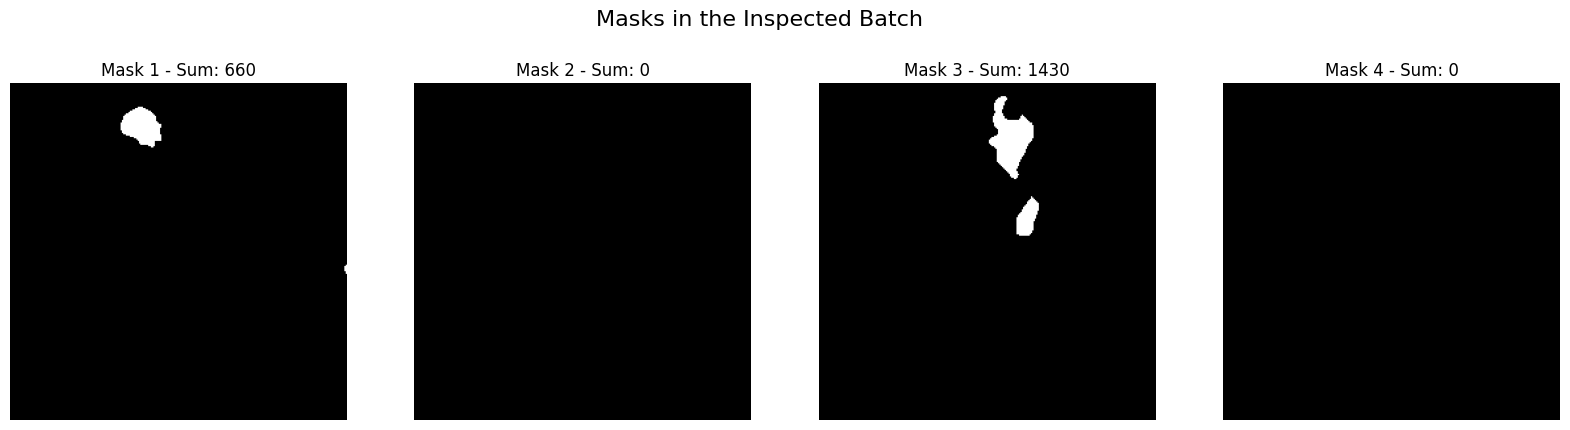


✅ SUCCESS: The batch contains masks with lakes.
You can now proceed with the tuned overfitting test.


In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import os
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# ===================================================================
# 1. The Corrected GlacialLakeDataset Class
# ===================================================================
class GlacialLakeDataset(Dataset):
    """Dataset with correct normalization for all 8 channels."""
    def __init__(self, image_dir, mask_dir, augmentations=None, target_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augmentations = augmentations
        self.target_size = target_size
        self.pairs = []
        
        image_files = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
        for img_path in image_files:
            filename = os.path.basename(img_path)
            if "input_stack_chunk" in filename:
                parts = filename.split("_")
                if len(parts) >= 5:
                    scene_id, chunk_id = parts[1], parts[-1].replace(".tif", "")
                    key = f"LISS3_{scene_id}_lake_mask_chunk_{chunk_id}.tif"
                    mask_path = os.path.join(self.mask_dir, key)
                    if os.path.exists(mask_path):
                        self.pairs.append((img_path, mask_path))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32)
        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)
        
        # --- Normalization Section ---
        # LISS-3 bands (channels 0-3)
        image[:4, :, :] = image[:4, :, :] / 1023.0 
        
        # Topographic bands (channels 4-7) - using placeholder max values
        DEM_MAX = 4000.0
        SLOPE_MAX = 90.0
        ASPECT_MAX = 360.0
        
        image[4, :, :] = image[4, :, :] / DEM_MAX 
        image[5, :, :] = image[5, :, :] / SLOPE_MAX
        image[6, :, :] = image[6, :, :] / ASPECT_MAX
        image[7, :, :] = (image[7, :, :] + 1.0) / 2.0 # Scale NDWI from [-1, 1] to [0, 1]

        image = np.clip(image, 0.0, 1.0)
        # --- End Normalization ---

        num_channels, h, w = image.shape
        padded_image = np.zeros((num_channels, self.target_size, self.target_size), dtype=np.float32)
        padded_mask = np.zeros((self.target_size, self.target_size), dtype=np.float32)
        padded_image[:, :h, :w] = image
        padded_mask[:h, :w] = mask
        
        if self.augmentations:
            augmented = self.augmentations(image=padded_image.transpose(1, 2, 0), mask=padded_mask)
            padded_image = augmented['image'].transpose(2, 0, 1)
            padded_mask = augmented['mask']
            
        return {"image": torch.from_numpy(padded_image), "mask": torch.from_numpy(padded_mask).unsqueeze(0)}

# ===================================================================
# 2. Setup and Batch Loading
# ===================================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\train"
TRAIN_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\train"

print("--- Loading dataset ---")
# Instantiate the dataset and loader
inspection_dataset = GlacialLakeDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MSK_DIR, target_size=256)
# IMPORTANT: Use shuffle=False to get a consistent batch for debugging
inspection_loader = DataLoader(inspection_dataset, batch_size=4, shuffle=False) 

# Get a single batch of data
try:
    batch_data = next(iter(inspection_loader))
    images = batch_data["image"].to(DEVICE)
    masks = batch_data["mask"].to(DEVICE)
    print("Batch loaded successfully.")
except StopIteration:
    print("The DataLoader is empty. Check your data directories and file matching logic.")
    exit()

# ===================================================================
# 3. Inspecting and Plotting the Batch
# ===================================================================
print("--- Inspecting the specific batch for overfitting ---")


# Convert masks to numpy for plotting.
# .squeeze(1) removes the channel dimension (e.g., [4, 1, 256, 256] -> [4, 256, 256])
masks_np = masks.cpu().numpy().squeeze(1) 

# Create a figure to display the 4 masks in the batch
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Masks in the Inspected Batch", fontsize=16)

for i in range(4):
    # Calculate the sum of pixel values in the mask.
    # A non-zero sum means there are white pixels (lakes).
    pixel_sum = np.sum(masks_np[i])
    
    axes[i].imshow(masks_np[i], cmap='gray')
    axes[i].set_title(f"Mask {i+1} - Sum: {pixel_sum:.0f}")
    axes[i].axis('off')

plt.show()

# Final check
if np.sum(masks_np) == 0:
    print("\n⚠️  WARNING: The entire batch contains empty masks (no lakes).")
    print("This is likely why the overfitting loss is not dropping to zero.")
    print("Try running the script again or use shuffle=True to get a different batch.")
else:
    print("\n✅ SUCCESS: The batch contains masks with lakes.")
    print("You can now proceed with the tuned overfitting test.")

### overfitting test

In [20]:
import torch.optim as optim
from tqdm.notebook import tqdm

# --- Re-run the overfitting test with a lower learning rate and more iterations ---
print("\n--- Re-running Overfitting Test with Tuned Hyperparameters ---")
try:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # We'll use the same batch as before (images, masks)
    
    # Re-initialize the model
    final_model = BugfixedUNET(n_channels=8, n_classes=1).to(DEVICE)
    
    # ✅ CHANGE 1: Use a lower learning rate
    optimizer = optim.Adam(final_model.parameters(), lr=1e-4) # Was 1e-3
    loss_fn = DiceBCELoss()
    
    final_model.train()
    
    # ✅ CHANGE 2: Increase iterations
    for i in tqdm(range(500), desc="Overfitting (Tuned)..."): # Was 200
        predictions = final_model(images)
        loss = loss_fn(predictions, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"\n✅ Final loss after TUNED overfitting: {loss.item():.6f}")
    print("This loss should now be much closer to zero.")

except Exception as e:
    print(f"An error occurred: {e}")


--- Re-running Overfitting Test with Tuned Hyperparameters ---


Overfitting (Tuned)...:   0%|          | 0/500 [00:00<?, ?it/s]


✅ Final loss after TUNED overfitting: 0.573342
This loss should now be much closer to zero.


## model test code

Loading best model from: unet_final_model.pth


C:\Users\Rochan\AppData\Local\Temp\ipykernel_10260\3326920199.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=

Plotting results... (Input | Ground Truth | Prediction)


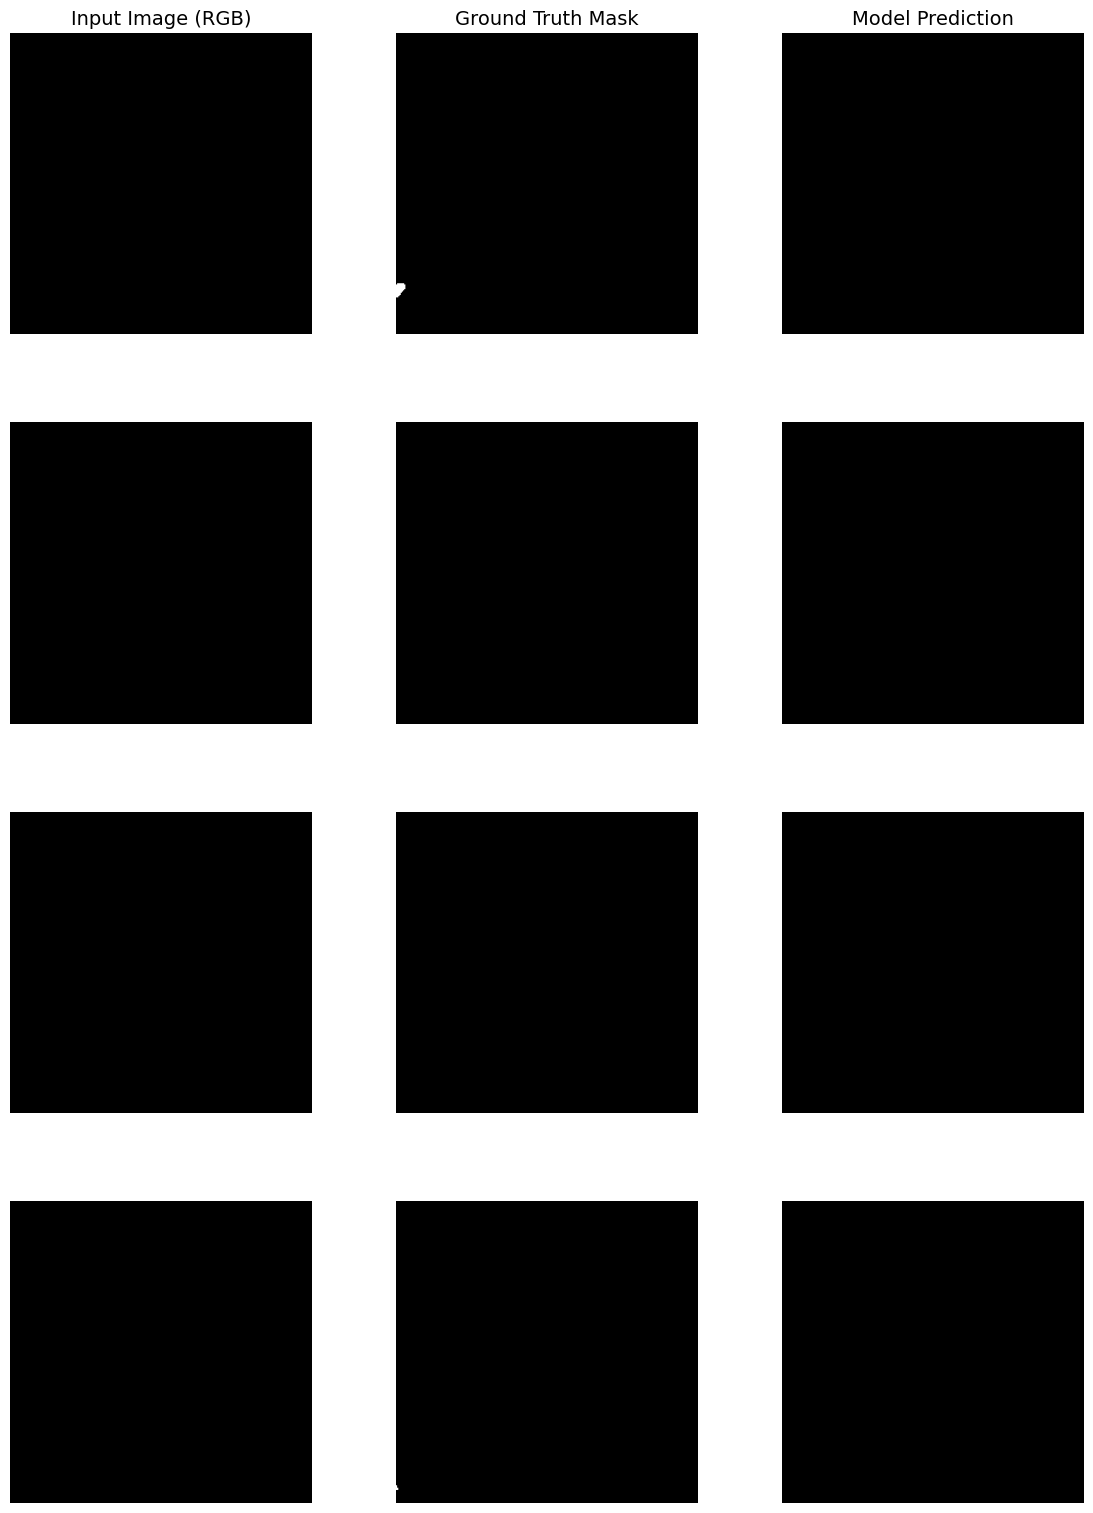

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ===================================================================
# IMPORTANT: Make sure the GlacialLakeDataset and BugfixedUNET classes
# from your training script are defined here or imported.
# ===================================================================

# --- Configuration ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "unet_final_model.pth" # The path to your saved model
VAL_IMG_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\input_stack\validate"
VAL_MSK_DIR = r"C:\Users\Rochan\Desktop\Coding\Glacial_Lale_Detection_BAH-2025\data\LISS3\segments\lake_mask\validate"

# --- 1. Load the data ---
val_dataset = GlacialLakeDataset(VAL_IMG_DIR, VAL_MSK_DIR, target_size=256)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=True) # Shuffle to see different images each run

# --- 2. Load the trained model ---
print(f"Loading best model from: {MODEL_PATH}")
model = BugfixedUNET(n_channels=8, n_classes=1).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval() # Set model to evaluation mode

# --- 3. Get a batch and make predictions ---
batch = next(iter(val_loader))
images = batch["image"].to(DEVICE)
ground_truth_masks = batch["mask"].to(DEVICE)

with torch.no_grad():
    # Get raw predictions (logits) from the model
    pred_logits = model(images)
    # Convert logits to probabilities using sigmoid
    pred_probs = torch.sigmoid(pred_logits)
    # Create binary masks based on a 0.5 threshold
    predicted_masks = (pred_probs > 0.5).float()

# --- 4. Move data to CPU and plot ---
# Convert tensors to NumPy arrays for plotting
images_np = images.cpu().numpy()
gt_np = ground_truth_masks.cpu().numpy().squeeze(1) # Remove channel dim
preds_np = predicted_masks.cpu().numpy().squeeze(1) # Remove channel dim

print("Plotting results... (Input | Ground Truth | Prediction)")
# Create a figure to display the results
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.tight_layout(pad=3.0)
axes[0, 0].set_title("Input Image (RGB)", fontsize=14)
axes[0, 1].set_title("Ground Truth Mask", fontsize=14)
axes[0, 2].set_title("Model Prediction", fontsize=14)

for i in range(4):
    # Create a displayable RGB image from the first few channels
    # Note: We assume channels [2, 1, 0] are R,G,B for visualization
    rgb_image = np.stack([images_np[i, 2, :, :], images_np[i, 1, :, :], images_np[i, 0, :, :]], axis=-1)
    
    # Clip values to [0, 1] just in case of any floating point artifacts
    rgb_image = np.clip(rgb_image, 0, 1)

    # Plot Input Image
    axes[i, 0].imshow(rgb_image)
    axes[i, 0].axis('off')

    # Plot Ground Truth
    axes[i, 1].imshow(gt_np[i], cmap='gray')
    axes[i, 1].axis('off')

    # Plot Prediction
    axes[i, 2].imshow(preds_np[i], cmap='gray')
    axes[i, 2].axis('off')

plt.show()

### Overfitting with Standard BCE Loss

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

# --- Final Diagnostic: Isolate the model using a standard loss function ---
print("\n--- Running Diagnostic Test: Overfitting with nn.BCEWithLogitsLoss ---")
try:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # We use the same batch (images, masks) that we inspected earlier.
    # The data is correct, so we don't need to reload it.
    
    # Re-initialize the model to start fresh
    final_model = BugfixedUNET(n_channels=8, n_classes=1).to(DEVICE)
    optimizer = optim.Adam(final_model.parameters(), lr=1e-4)
    
    # ✅ KEY CHANGE: Use the standard, stable PyTorch loss function.
    # This function includes the sigmoid activation internally for numerical stability.
    loss_fn = nn.BCEWithLogitsLoss()
    
    final_model.train()
    
    for i in tqdm(range(500), desc="Diagnostic Overfitting..."):
        # Get model predictions (these are raw logits)
        predictions = final_model(images)
        
        # Calculate loss
        loss = loss_fn(predictions, masks)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"\n✅ Final loss after diagnostic test: {loss.item():.6f}")
    print("If this loss is near zero, the model is OK, but the DiceBCELoss is faulty.")
    print("If this loss is still high, the BugfixedUNET model is the problem.")

except Exception as e:
    print(f"An error occurred: {e}")


--- Running Diagnostic Test: Overfitting with nn.BCEWithLogitsLoss ---


Diagnostic Overfitting...:   0%|          | 0/500 [00:00<?, ?it/s]


✅ Final loss after diagnostic test: 0.161461
If this loss is near zero, the model is OK, but the DiceBCELoss is faulty.
If this loss is still high, the BugfixedUNET model is the problem.
